In [3]:
!pip install -q datasets

import pandas as pd
import html
import re
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer

print("[INFO] Memulai Ulang Pipeline dari Awal di Sesi yang Segar...")

# 1. DOWNLOAD DATASET
print("[INFO] 1. Mengunduh Dataset...")
dataset = load_dataset("w11wo/reddit_indonesia_sarcastic", trust_remote_code=True)
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])

# 2. PREPROCESSING
print("[INFO] 2. Membersihkan Teks...")
kamus_gaul = {
    "yg": "yang", "tdk": "tidak", "y": "ya", "x": "kali",
    "g": "nggak", "ngga": "nggak", "ga": "nggak", "gk": "nggak", "gak": "nggak",
    "gbs": "nggak bisa", "kl": "kalau", "bs": "bisa", "skrg": "sekarang",
    "lgsg": "langsung", "gw": "gue", "guwe": "gue", "tp": "tapi",
    "bkn": "bukan", "udh": "sudah", "udah": "sudah", "dah": "sudah",
    "tu": "itu", "ni": "ini", "nih": "ini", "dgn": "dengan",
    "pk": "pakai", "pake": "pakai", "loe": "lu", "elu": "lu",
    "cowo": "cowok", "cewe": "cewek", "bosen": "bosan", "males": "malas",
    "bener": "benar", "serem": "seram", "sirem": "siram",
    "njir": "anjir", "jir": "anjir", "anjim": "anjir", "tau": "tahu",
    "gmn": "bagaimana", "gimana": "bagaimana"
}

def preprocessing_teks(teks):
    if not isinstance(teks, str): return ""
    teks = html.unescape(teks.lower())
    teks = " ".join([kamus_gaul.get(k, k) for k in teks.split()])
    teks = re.sub(r'(.)\1{2,}', r'\1\1', teks)
    teks = re.sub(r'\b(\w+)(?:2|")\b', r'\1-\1', teks)
    return teks.strip()

df_train['text_bersih'] = df_train['text'].apply(preprocessing_teks)
df_test['text_bersih'] = df_test['text'].apply(preprocessing_teks)

df_train = df_train.dropna(subset=['text_bersih', 'label'])
df_test = df_test.dropna(subset=['text_bersih', 'label'])

# 3. TOKENISASI
print("[INFO] 3. Tokenisasi...")
hf_train = Dataset.from_pandas(df_train[['text_bersih', 'label']])
hf_test = Dataset.from_pandas(df_test[['text_bersih', 'label']])

nama_model = "cahya/distilbert-base-indonesian"
tokenizer = AutoTokenizer.from_pretrained(nama_model)

def tokenisasi(batch):
    return tokenizer(batch["text_bersih"], padding="max_length", truncation=True, max_length=128)

tokenized_train = hf_train.map(tokenisasi, batched=True)
tokenized_test = hf_test.map(tokenisasi, batched=True)

print("[SUKSES] Seluruh Pipeline Data Selesai! Variabel 'tokenized_train' sudah siap.")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'w11wo/reddit_indonesia_sarcastic' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'w11wo/reddit_indonesia_sarcastic' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


[INFO] Memulai Ulang Pipeline dari Awal di Sesi yang Segar...
[INFO] 1. Mengunduh Dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train.json:   0%|          | 0.00/4.29M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/9881 [00:00<?, ? examples/s]

Map:   0%|          | 0/2824 [00:00<?, ? examples/s]

[SUKSES] Seluruh Pipeline Data Selesai! Variabel 'tokenized_train' sudah siap.


In [4]:
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

torch.cuda.empty_cache()

nama_model = "cahya/distilbert-base-indonesian"
print(f"[INFO] Memuat ulang arsitektur model {nama_model}...")
model = AutoModelForSequenceClassification.from_pretrained(nama_model, num_labels=2)

path_model = "/content/drive/MyDrive/NLP_Sarkasme/Model_Hasil"

training_args = TrainingArguments(
    output_dir=path_model,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    fp16=True,
    eval_strategy="no",
    save_strategy="epoch",
    logging_steps=50,
    save_total_limit=1
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    )

print("[INFO] Memulai proses Blind Training (Fokus Belajar). Tunggu sekitar 10-15 menit...")
trainer.train()
print("\n[SUKSES] Proses Belajar Selesai 100%!")

[INFO] Memuat ulang arsitektur model cahya/distilbert-base-indonesian...


pytorch_model.bin:   0%|          | 0.00/273M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/273M [00:00<?, ?B/s]

DistilBertForSequenceClassification LOAD REPORT from: cahya/distilbert-base-indonesian
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Step,Training Loss
50,2.145588
100,1.812617
150,1.840215
200,1.869977
250,1.760920
300,1.710980
350,1.391747
400,1.239534
450,1.215975
500,1.303834


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[SUKSES] Proses Belajar Selesai 100%!


In [5]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification
from transformers.trainer_utils import get_last_checkpoint
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

torch.cuda.empty_cache()

path_model = "/content/drive/MyDrive/NLP_Sarkasme/Model_Hasil"
checkpoint_terakhir = get_last_checkpoint(path_model)
print(f"[INFO] Memuat otak model dari:\n{checkpoint_terakhir}\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_pintar = AutoModelForSequenceClassification.from_pretrained(checkpoint_terakhir, num_labels=2)
model_pintar.to(device)
model_pintar.eval()

tokenized_test.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
dataloader_ujian = DataLoader(tokenized_test, batch_size=16)

semua_tebakan = []
semua_label = []

print("[INFO] Memulai ujian manual tahap demi tahap...")

for batch in tqdm(dataloader_ujian, desc="Mengerjakan Soal"):
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['label'].to(device)


    with torch.no_grad():
        outputs = model_pintar(input_ids, attention_mask=attention_mask)
        tebakan_batch = torch.argmax(outputs.logits, dim=-1)

    semua_tebakan.extend(tebakan_batch.cpu().numpy())
    semua_label.extend(labels.cpu().numpy())

    del input_ids, attention_mask, labels, outputs, tebakan_batch
    torch.cuda.empty_cache()

f1 = f1_score(semua_label, semua_tebakan, average='macro')
acc = accuracy_score(semua_label, semua_tebakan)

print(f"\n=======================================")
print(f" HASIL AKHIR DETEKSI SARKASME (NOVELTY)")
print(f"=======================================")
print(f" Akurasi  : {acc:.4f}")
print(f" F1-Score : {f1:.4f}")
print(f"=======================================")

[INFO] Memuat otak model dari:
/content/drive/MyDrive/NLP_Sarkasme/Model_Hasil/checkpoint-927



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[INFO] Memulai ujian manual tahap demi tahap...


Mengerjakan Soal: 100%|██████████| 177/177 [00:10<00:00, 16.35it/s]


 HASIL AKHIR DETEKSI SARKASME (NOVELTY)
 Akurasi  : 0.7964
 F1-Score : 0.7183


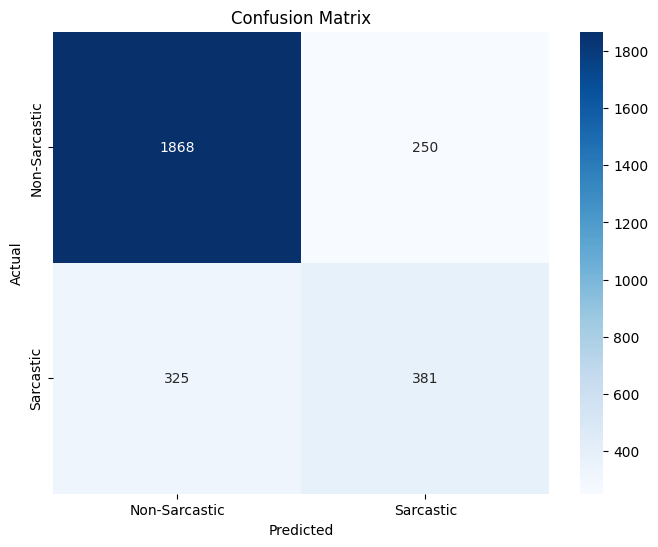

Classification Report:

               precision    recall  f1-score   support

Non-Sarcastic       0.85      0.88      0.87      2118
    Sarcastic       0.60      0.54      0.57       706

     accuracy                           0.80      2824
    macro avg       0.73      0.71      0.72      2824
 weighted avg       0.79      0.80      0.79      2824



In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(semua_label, semua_tebakan)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Sarcastic', 'Sarcastic'], yticklabels=['Non-Sarcastic', 'Sarcastic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print('Classification Report:\n')
print(classification_report(semua_label, semua_tebakan, target_names=['Non-Sarcastic', 'Sarcastic']))